In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
import glob

import torch
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

sys.path.append("../")

from oxels.datasets import PerspectiveImagesDataset
from oxels.networks import SwinUNet
from oxels.losses import original_loss_func
from oxels.augmentation import HueShift, MotionBlur, RandomKernel, RandomBrightnessContrast, PixelNoise, Sobel, Scharr, SequenceStrategy

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
#"harmless" augmentations
basic_augmentations = SequenceStrategy(
    [MotionBlur(), HueShift(), RandomBrightnessContrast()],
    probabilities=[0.8,0.8,0.8],
    ordered=False,
    at_most_one=False)

#more disruptive augmentations that should be applied sparsingly and collide with one another
advanced_agumentation = SequenceStrategy(
    [RandomKernel(), Sobel(), Scharr(), PixelNoise()],
    probabilities=None,
    ordered=False,
    at_most_one=True)

#all augmentations (order matters)
all_agumentations = SequenceStrategy(
    [basic_augmentations, advanced_agumentation],
    probabilities=[1.0, 0.2],
    ordered=True,
    at_most_one=False)

In [4]:
files = glob.glob("../../Pictures/Screenshots/*.png")
dataset = PerspectiveImagesDataset(files, all_agumentations, 256+128, 256, 0.5)

In [5]:
loader = DataLoader(
    dataset,
    batch_size=4,      # whatever batch size you want
    num_workers=1,      # parallel data loading
    pin_memory=True,    # if you’re on CUDA
)

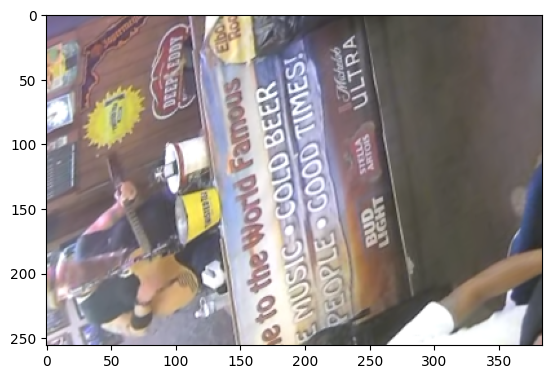

In [6]:
view1, view2, permutation, flags, mask1, mask2 = next(iter(loader))
plt.imshow(view1[0].detach().numpy().transpose((1,2,0)))

In [7]:
network = SwinUNet(height=256, width=256+128, channels=3, patch_size=4, num_stages=5, head_dim=64, patch_embed_dim=16, oxel_dim=32).to(device)

In [8]:
%%time
with torch.no_grad():
    oxels1 = network(view1.to(device))
    oxels2 = network(view2.to(device))
    print(original_loss_func(oxels1, oxels2, permutation.to(device), flags.to(device), mask1.to(device), mask2.to(device)))

tensor(0.7393, device='cuda:0')
CPU times: user 104 ms, sys: 73.2 ms, total: 177 ms
Wall time: 175 ms


In [ ]:
EPOCHS = 5000
LEARNING_RATE = 5e-5

optimizer = torch.optim.Adam(network.parameters(), lr=LEARNING_RATE)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

for epoch in range(EPOCHS):
    network.train()
    total_loss = 0.0

    for view1, view2, permutation, flags, mask1, mask2 in loader:
        view1 = view1.to(device)
        view2 = view2.to(device)
        permutation = permutation.to(device)
        flags = flags.to(device)
        mask1 = mask1.to(device)
        mask2 = mask2.to(device)

        optimizer.zero_grad()
        oxels1 = network(view1)
        oxels2 = network(view2)

        loss = original_loss_func(oxels1, oxels2, permutation, flags, mask1, mask2)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()  # update learning rate

    avg_loss = total_loss / len(loader)
    print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {avg_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.2e}")

    # Save model checkpoint
    # torch.save(network.state_dict(), f"../checkpoints/checkpoint_epoch_{epoch+1}.pth")

Epoch 1/5000, Loss: 0.7535, LR: 5.00e-05
Epoch 2/5000, Loss: 0.7419, LR: 5.00e-05
Epoch 3/5000, Loss: 0.7801, LR: 5.00e-05
Epoch 4/5000, Loss: 0.7276, LR: 5.00e-05
Epoch 5/5000, Loss: 0.7061, LR: 5.00e-05
Epoch 6/5000, Loss: 0.7235, LR: 5.00e-05
Epoch 7/5000, Loss: 0.6724, LR: 5.00e-05
Epoch 8/5000, Loss: 0.6621, LR: 5.00e-05
Epoch 9/5000, Loss: 0.6691, LR: 5.00e-05
Epoch 10/5000, Loss: 0.6796, LR: 5.00e-05
Epoch 11/5000, Loss: 0.6516, LR: 5.00e-05
Epoch 12/5000, Loss: 0.6850, LR: 5.00e-05
Epoch 13/5000, Loss: 0.6541, LR: 5.00e-05
Epoch 14/5000, Loss: 0.6517, LR: 5.00e-05
Epoch 15/5000, Loss: 0.6304, LR: 5.00e-05
Epoch 16/5000, Loss: 0.6259, LR: 5.00e-05
Epoch 17/5000, Loss: 0.6060, LR: 5.00e-05
Epoch 18/5000, Loss: 0.6254, LR: 5.00e-05
Epoch 19/5000, Loss: 0.6177, LR: 5.00e-05
Epoch 20/5000, Loss: 0.6026, LR: 5.00e-05
Epoch 21/5000, Loss: 0.6066, LR: 5.00e-05
Epoch 22/5000, Loss: 0.5921, LR: 5.00e-05
Epoch 23/5000, Loss: 0.5869, LR: 5.00e-05
Epoch 24/5000, Loss: 0.5929, LR: 5.00e-05
E

In [12]:
torch.save(network.state_dict(), f"../checkpoints/checkpoint_epoch_{epoch+1}.pth")

In [ ]:
files = glob.glob("../../schenectadata/image-matching-challenge-2022/train/*/images/*.jpg")